In [ ]:
%load_ext autoreload
%autoreload 2

import os
os.environ['MUJOCO_GL'] = 'egl'

In [84]:
import sys

sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")
from analysis.utils import reconstruct_cartpole_dmcontrol
from envs import make_env
from omegaconf import OmegaConf
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from tqdm import tqdm

In [163]:
from analysis.utils import load_sweep_metadata, load_data
from analysis.utils import chunk_data
from analysis.utils_data_generation import collect_data
from analysis.utils_data_generation import run_env_autonomous
from analysis.utils_data_generation import sample_uniform_obs
import umap
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

## UTILS

In [37]:
def stack_consecutive_frames(frames):
    """
    Convert frames (N, 64, 64, 3) to stacked frames (N, 9, 64, 64) with channels-first format.
    Pads the start with two duplicates of the first frame.
    
    Args:
        frames (np.ndarray): Input frames, shape (N, 64, 64, 3)
    Returns:
        stacked (np.ndarray): Output stacked frames, shape (N, 9, 64, 64)
    """
    assert frames.ndim == 4 and frames.shape[1:] == (64, 64, 3), \
        f"Expected input of shape (N, 64, 64, 3), got {frames.shape}"

    # Convert to channels-first: (N, 3, 64, 64)
    frames_chw = np.transpose(frames, (0, 3, 1, 2))
    assert frames_chw.shape[1:] == (3, 64, 64), \
        f"After transpose, expected (N, 3, 64, 64), got {frames_chw.shape}"

    # Pad the beginning by repeating the first frame twice
    first_frame = frames_chw[0:1, ...]  # (1, 3, 64, 64)
    padded = np.concatenate([first_frame, first_frame, frames_chw],
                            axis=0)  # (N+2, 3, 64, 64)
    assert padded.shape[0] == frames_chw.shape[0] + 2

    # Stack 3 consecutive frames → (N, 9, 64, 64)
    chunk_1 = padded[:-2]  # frame t
    chunk_2 = padded[1:-1]  # frame t+1
    chunk_3 = padded[2:]  # frame t+2
    assert chunk_1.shape == chunk_2.shape == chunk_3.shape

    stacked = np.concatenate([chunk_1, chunk_2, chunk_3],
                             axis=1)  # (N, 9, 64, 64)
    assert stacked.shape[1:] == (9, 64, 64), \
        f"Output shape should be (N, 9, 64, 64), got {stacked.shape}"

    return stacked


def chunk_data_and_stack(frames):
    frames_chunked = chunk_data(frames, 500)
    stacked_frames = []
    for chunk in frames_chunked:
        stacked_frames.append(stack_consecutive_frames(chunk))
    return np.concatenate(stacked_frames, axis=0)


def plot_frames(frames, idx=0):
    """
    Plot the 3 consecutive frames for a given stacked sample.
    
    Args:
        stacked (np.ndarray): Array of shape (N, 9, 64, 64)
        idx (int): which stacked sample to plot
    """
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for i, ax in enumerate(axes):
        ax.imshow(frames[idx][i * 3:(i + 1) * 3].transpose(1, 2, 0))
        ax.set_title(f'Frame {i}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## In policy data

In [43]:
CKPT_TO_USE = 500_000
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))
df = df[df['ckpt_int'] == CKPT_TO_USE]
z_inpolicy = np.concatenate(df['latent_states'].tolist())
obs_inpolicy = np.concatenate(df['observations'].tolist())
actions_inpolicy = np.concatenate(df['actions'].tolist())
rewards_inpolicy = np.concatenate(df['rewards'].tolist()).reshape(-1, 1)

frames_inpolicy_dreamer = reconstruct_cartpole_dmcontrol(obs_inpolicy,
                                                         height=64,
                                                         width=64,
                                                         return_frames=True)
frames_inpolicy_dreamer = np.array(frames_inpolicy_dreamer)

frames_inpolicy_tdmpc2 = chunk_data_and_stack(frames_inpolicy_dreamer)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 226.38it/s]


Found 108 configurations
Found 108 configurations


100%|██████████| 9000/9000 [01:27<00:00, 103.36it/s]


In [44]:
obs_inpolicy.shape, frames_inpolicy_dreamer.shape, frames_inpolicy_tdmpc2.shape, actions_inpolicy.shape, rewards_inpolicy.shape

((9000, 5), (9000, 64, 64, 3), (9000, 9, 64, 64), (9000, 1), (9000, 1))

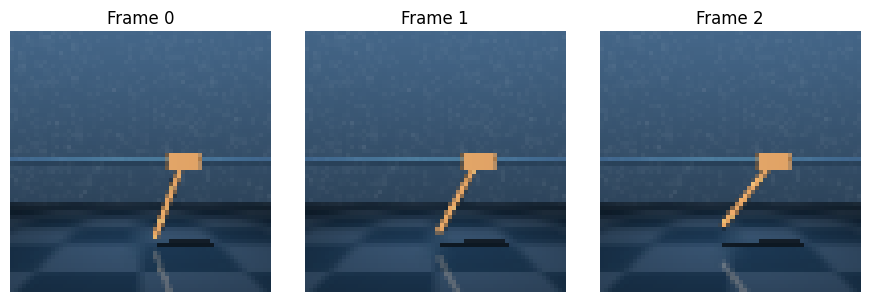

In [45]:
# Example usage:
plot_frames(frames_inpolicy_tdmpc2, idx=30)

In [47]:
data_in_policy = {
    'obs_states': obs_inpolicy,
    'obs_pixels_dreamer': frames_inpolicy_dreamer,
    'obs_pixels_tdmpc2': frames_inpolicy_tdmpc2,
    'actions': actions_inpolicy,
    'rewards': rewards_inpolicy,
}

# Directory to save data
save_dir = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation'
os.makedirs(save_dir, exist_ok=True)

# Save data for in-policy, off-policy, and passive episodes
with open(os.path.join(save_dir, 'data_in_policy.pkl'), 'wb') as f:
    pickle.dump(data_in_policy, f)

## Off policy data: Collect data with OU policy from state, and then convert to frames.

In [49]:
cfg_state = OmegaConf.create({
    'task': 'cartpole-swingup',
    'obs': 'state',
    'seed': 0,
    'multitask': False,
})

env_state = make_env(cfg_state)

In [51]:
initial_positions = [-1.5, -1, 0, 1, 1.5]
initial_angles = np.radians(np.linspace(0, 360, 10))

initial_states = []
for initial_position in initial_positions:
    for initial_angle in initial_angles:
        initial_states.append(
            {
                'qpos': {
                    'slider': initial_position,
                    'hinge_1': initial_angle,
                },
                'qvel': {
                    'slider': 0.0,
                    'hinge_1': 0.0
                }
            },)

steps_episode = 500
episodes_offpolicy = collect_data(env_state,
                                  max_steps=steps_episode,
                                  seed=1,
                                  initial_states=initial_states,
                                  n_episodes_per_initial_state=1,
                                  is_rgb=False)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:09<00:00,  5.30it/s]


In [139]:
obs_episodes_offpolicy = []
rewards_episodes_offpolicy = []
actions_episodes_offpolicy = []
obs_episodes_pixel_offpolicy = []
for j in range(len(episodes_offpolicy)):
    obs_episode = np.array(
        [episodes_offpolicy[j][i]['obs_next'] for i in range(steps_episode)])
    obs_episode_pixel = np.array([
        episodes_offpolicy[j][i]['obs_next_pixel'] for i in range(steps_episode)
    ])
    actions_episode = np.array(
        [episodes_offpolicy[j][i]['action'] for i in range(steps_episode)])
    rewards_episode = np.array(
        [episodes_offpolicy[j][i]['reward'] for i in range(steps_episode)])
    obs_episodes_offpolicy.append(obs_episode)
    obs_episodes_pixel_offpolicy.append(obs_episode_pixel)
    rewards_episodes_offpolicy.append(rewards_episode)
    actions_episodes_offpolicy.append(actions_episode)

obs_episodes_offpolicy = np.concatenate(obs_episodes_offpolicy, axis=0)
obs_episodes_pixel_offpolicy = np.concatenate(obs_episodes_pixel_offpolicy,
                                              axis=0)
actions_episodes_offpolicy = np.concatenate(actions_episodes_offpolicy, axis=0)
rewards_episodes_offpolicy = np.concatenate(rewards_episodes_offpolicy,
                                            axis=0).reshape(-1, 1)

obs_episodes_offpolicy.shape, obs_episodes_pixel_offpolicy.shape, actions_episodes_offpolicy.shape, rewards_episodes_offpolicy.shape

((25000, 5), (25000,), (25000, 1), (25000, 1))

In [54]:
frames_offpolicy_dreamer = reconstruct_cartpole_dmcontrol(
    obs_episodes_offpolicy, height=64, width=64, return_frames=True)
frames_offpolicy_dreamer = np.array(frames_offpolicy_dreamer)
frames_offpolicy_tdmpc2 = chunk_data_and_stack(frames_offpolicy_dreamer)

100%|██████████| 25000/25000 [03:43<00:00, 112.02it/s]


In [166]:
frames_offpolicy_dreamer.shape, frames_offpolicy_tdmpc2.shape

((25000, 64, 64, 3), (25000, 9, 64, 64))

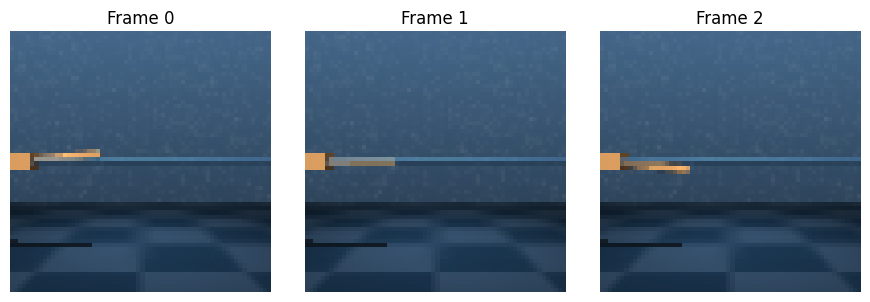

In [74]:
# Example usage:
plot_frames(frames_offpolicy_tdmpc2, idx=520)

In [167]:
data_off_policy = {
    'obs_states': obs_episodes_offpolicy,
    'obs_pixels_dreamer': frames_offpolicy_dreamer,
    'obs_pixels_tdmpc2': frames_offpolicy_tdmpc2,
    'actions': actions_episodes_offpolicy,
    'rewards': rewards_episodes_offpolicy,
}

# Directory to save data
save_dir = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation'
os.makedirs(save_dir, exist_ok=True)

# Save data for in-policy, off-policy, and passive episodes
with open(os.path.join(save_dir, 'data_off_policy.pkl'), 'wb') as f:
    pickle.dump(data_off_policy, f)

## Passive and Uniform data:

1. Sample initial states from uniform distribution --> Uniform data
2. Select some of them to follow passive dynamics --> Passive data

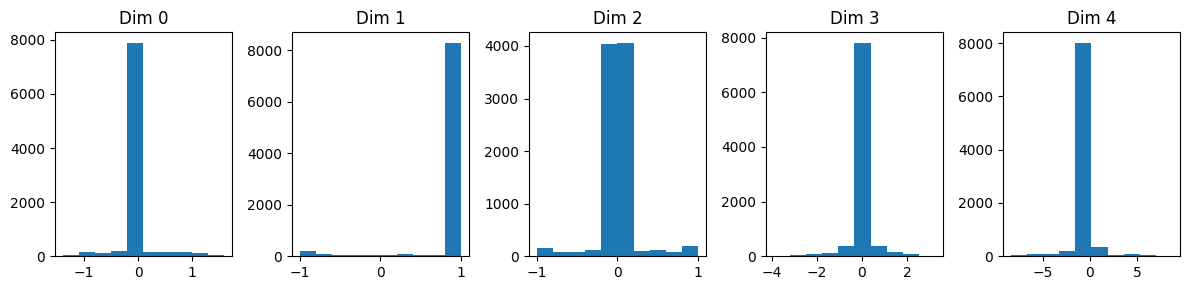

In [97]:
plt.figure(figsize=(12, 3))
for i in range(obs_inpolicy.shape[1]):
    plt.subplot(1, obs_inpolicy.shape[1], i + 1)
    plt.hist(obs_inpolicy[:, i])
    plt.title(f"Dim {i}")
plt.tight_layout()
plt.show()

In [110]:
obs_uniform = sample_uniform_obs(n=30_000,
                                 sample_cart_velocity_normal=True,
                                 cart_velocity_normal_params=(0.0, 0.8),
                                 sample_angular_velocity_normal=True,
                                 angular_velocity_params=(0.0, 2.0))


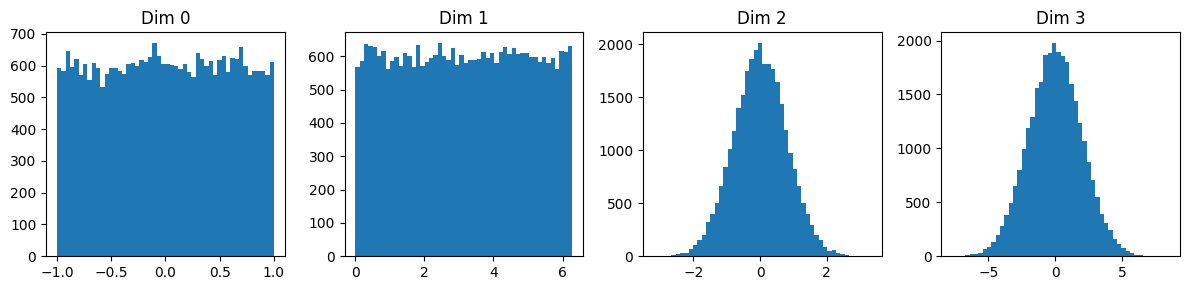

In [119]:
plt.figure(figsize=(12, 3))
for i in range(obs_uniform.shape[1]):
    plt.subplot(1, obs_uniform.shape[1], i + 1)
    plt.hist(obs_uniform[:, i], bins=50)
    plt.title(f"Dim {i}")
plt.tight_layout()
plt.show()

In [113]:
initial_states_passive = obs_uniform[np.random.choice(range(len(obs_uniform)),
                                                      size=500,
                                                      replace=False)]

In [124]:
obs_passive_list = []
actions_passive_list = []
rewards_passive_list = []
steps_to_run = 100
for initial_state in tqdm(initial_states_passive):
    initial_state = {
        'qpos': {
            'slider': initial_state[0],
            'hinge_1': initial_state[1],
        },
        'qvel': {
            'slider': initial_state[2],
            'hinge_1': initial_state[3]
        }
    }
    obs_passive, actions_passive, rewards_passive = run_env_autonomous(
        env_state,
        initial_state=initial_state,
        n_steps=steps_to_run,
        is_rgb=False)
    obs_passive_list.append(obs_passive)
    actions_passive_list.append(actions_passive)
    rewards_passive_list.append(rewards_passive)

obs_passive = np.concatenate([ep for ep in obs_passive_list if ep is not None],
                             axis=0)
actions_passive = np.concatenate(
    [ep for ep in actions_passive_list if ep is not None], axis=0)
rewards_passive = np.concatenate(
    [ep for ep in rewards_passive_list if ep is not None],
    axis=0).reshape(-1, 1)

100%|██████████| 500/500 [00:16<00:00, 29.80it/s]


In [127]:
obs_passive.shape, actions_passive.shape, rewards_passive.shape

((50000, 5), (50000, 1), (50000, 1))

In [128]:
reconstruct_cartpole_dmcontrol(obs_passive_list[20],
                               height=180,
                               width=200,
                               show=True)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 66.33it/s]
[swscaler @ 0x5a698c0] Warning: data is not aligned! This can lead to a speed loss


In [130]:
frames_passive_dreamer = reconstruct_cartpole_dmcontrol(obs_passive,
                                                        height=64,
                                                        width=64,
                                                        return_frames=True)
frames_passive_dreamer = np.array(frames_passive_dreamer)
frames_passive_tdmpc2 = chunk_data_and_stack(frames_passive_dreamer)

frames_passive_dreamer.shape, frames_passive_tdmpc2.shape

100%|██████████| 50000/50000 [08:19<00:00, 100.08it/s]


((50000, 64, 64, 3), (50000, 9, 64, 64))

In [131]:
data_passive = {
    'obs_states': obs_passive,
    'obs_pixels_dreamer': frames_passive_dreamer,
    'obs_pixels_tdmpc2': frames_passive_tdmpc2,
    'actions': actions_passive,
    'rewards': rewards_passive,
}

with open(os.path.join(save_dir, 'data_passive.pkl'), 'wb') as f:
    pickle.dump(data_passive, f)

### convert to frames uniform and save

In [144]:
obs_uniform = sample_uniform_obs(n=30_000,
                                 sample_cart_velocity_normal=True,
                                 cart_velocity_normal_params=(0.0, 0.8),
                                 sample_angular_velocity_normal=True,
                                 angular_velocity_params=(0.0, 2.0),
                                 return_as_state=True)

In [145]:
frames_uniform_dreamer = reconstruct_cartpole_dmcontrol(obs_uniform,
                                                        height=64,
                                                        width=64,
                                                        return_frames=True)
frames_uniform_dreamer = np.array(frames_uniform_dreamer)
frames_uniform_tdmpc2 = chunk_data_and_stack(frames_uniform_dreamer)

frames_uniform_dreamer.shape, frames_uniform_tdmpc2.shape


100%|██████████| 30000/30000 [04:42<00:00, 106.32it/s]


((30000, 64, 64, 3), (30000, 9, 64, 64))

In [146]:
reconstruct_cartpole_dmcontrol(obs_uniform[:500],
                               height=180,
                               width=200,
                               show=True)

100%|██████████| 500/500 [00:06<00:00, 74.74it/s]
[swscaler @ 0x69c38c0] Warning: data is not aligned! This can lead to a speed loss


In [147]:
data_uniform = {
    'obs_states': obs_uniform,
    'obs_pixels_dreamer': frames_uniform_dreamer,
    'obs_pixels_tdmpc2': frames_uniform_tdmpc2,
}

with open(os.path.join(save_dir, 'data_uniform.pkl'), 'wb') as f:
    pickle.dump(data_uniform, f)


## UMAP plot

In [164]:
obs_inpolicy.shape, obs_episodes_offpolicy.shape, obs_passive.shape, obs_uniform.shape

((9000, 5), (25000, 5), (50000, 5), (30000, 5))

In [150]:
def downsample(X, max_n=5000, rng=0):
    np.random.seed(rng)
    if len(X) > max_n:
        idx = np.random.choice(len(X), max_n, replace=False)
        return X[idx]
    else:
        return X


X_in_policy_ds = downsample(obs_inpolicy)
X_off_policy_ds = downsample(obs_episodes_offpolicy)
X_passive_ds = downsample(obs_passive)
X_uniform_ds = downsample(obs_uniform)

# Stack all and label
X_umap = np.concatenate(
    [X_in_policy_ds, X_off_policy_ds, X_passive_ds, X_uniform_ds], axis=0)

# Colors for each group (for plotting later), add 'gray' for uniform
label_to_color = {
    "In-policy": "tab:blue",
    "Off-policy": "tab:orange",
    "Passive": "tab:green",
    "Uniform": "gray"
}

# Run UMAP
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.2, random_state=42)
X_umap_proj = umap_model.fit_transform(X_umap)


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [161]:
labels = (["In-policy"] * len(X_in_policy_ds) +
          ["Off-policy"] * len(X_off_policy_ds) +
          ["Passive"] * len(X_passive_ds) + ["Uniform"] * len(X_uniform_ds))


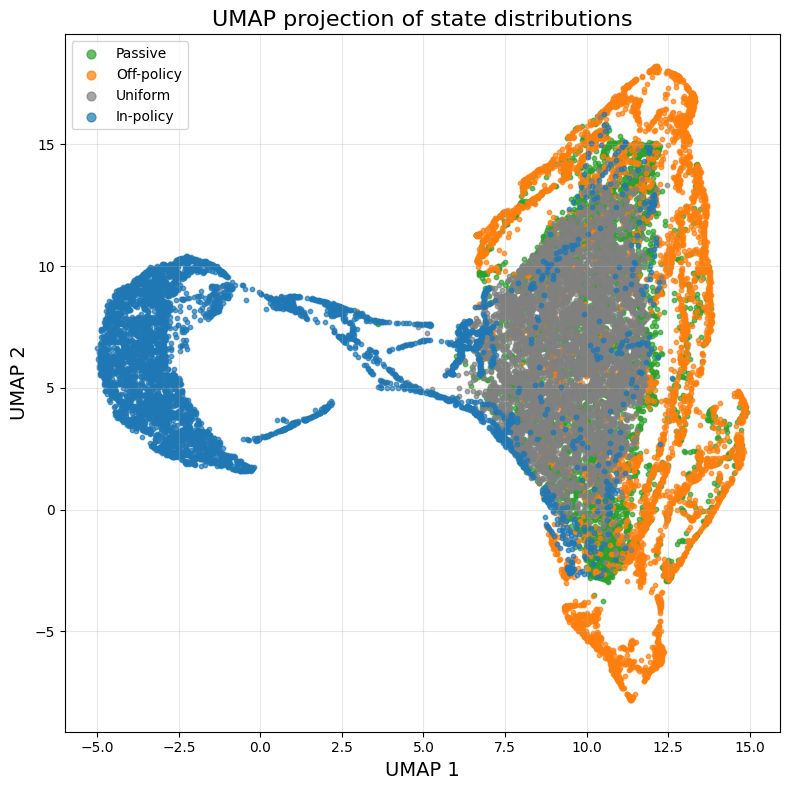

In [ ]:
plt.figure(figsize=(8, 8))
for label in set(set(labels)):
    idxs = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(X_umap_proj[idxs, 0],
                X_umap_proj[idxs, 1],
                label=label,
                s=10,
                alpha=0.7,
                color=label_to_color[label])
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)
plt.title("UMAP projection of state distributions", fontsize=16)
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
#plt.ylim(None, 10)
plt.tight_layout()
plt.show()